In [1]:
# Celda 1 — Instalar dependencias y montar Drive
!pip install wandb xgboost lightgbm catboost -q
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from google.colab import drive
import pickle
import wandb
from google.colab import userdata

wandb.login(key=userdata.get('WANDB_API_KEY'))

warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(42)

drive.mount("/content/drive")
DRIVE_PATH = "/content/drive/MyDrive/ProyectoHIGGS/"

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
print("Setup completado.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: diego-munozc (diego-munozc-universidad-de-antioquia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Mounted at /content/drive
Setup completado.


In [2]:
# Celda 2 — Cargar splits desde Drive
X_train = np.load(DRIVE_PATH + "X_train.npy")
X_val   = np.load(DRIVE_PATH + "X_val.npy")
X_test  = np.load(DRIVE_PATH + "X_test.npy")
y_train = np.load(DRIVE_PATH + "y_train.npy")
y_val   = np.load(DRIVE_PATH + "y_val.npy")
y_test  = np.load(DRIVE_PATH + "y_test.npy")

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (350000, 28), Val: (75000, 28), Test: (75000, 28)


In [3]:
# Celda 3 — Función de evaluación (5-Fold CV, scaler por fold)
def evaluar_modelo_cv(model, X_train, y_train, X_val, y_val, X_test, y_test,
                      nombre, k=5, use_scaler=True):
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    auc_folds, f1_folds, acc_folds, prec_folds, rec_folds = [], [], [], [], []

    for tr_idx, vl_idx in kf.split(X_train, y_train):
        if use_scaler:
            scaler_cv = StandardScaler()
            X_tr_fold = scaler_cv.fit_transform(X_train[tr_idx])
            X_vl_fold = scaler_cv.transform(X_train[vl_idx])
        else:
            X_tr_fold = X_train[tr_idx]
            X_vl_fold = X_train[vl_idx]
        model.fit(X_tr_fold, y_train[tr_idx])
        y_prob = model.predict_proba(X_vl_fold)[:, 1]
        y_pred = model.predict(X_vl_fold)
        auc_folds.append(roc_auc_score(y_train[vl_idx], y_prob))
        f1_folds.append(f1_score(y_train[vl_idx], y_pred))
        acc_folds.append(accuracy_score(y_train[vl_idx], y_pred))
        prec_folds.append(precision_score(y_train[vl_idx], y_pred))
        rec_folds.append(recall_score(y_train[vl_idx], y_pred))

    scaler = StandardScaler()
    if use_scaler:
        X_train_sc = scaler.fit_transform(X_train)
        X_val_sc   = scaler.transform(X_val)
        X_test_sc  = scaler.transform(X_test)
    else:
        X_train_sc, X_val_sc, X_test_sc = X_train, X_val, X_test
    model.fit(X_train_sc, y_train)

    return {
        "Modelo": nombre,
        "AUC_CV_mean": np.mean(auc_folds), "AUC_CV_std": np.std(auc_folds),
        "F1_CV_mean": np.mean(f1_folds),   "F1_CV_std": np.std(f1_folds),
        "Acc_CV_mean": np.mean(acc_folds), "Acc_CV_std": np.std(acc_folds),
        "Precision_CV_mean": np.mean(prec_folds), "Precision_CV_std": np.std(prec_folds),
        "Recall_CV_mean": np.mean(rec_folds), "Recall_CV_std": np.std(rec_folds),
        "AUC_val": roc_auc_score(y_val,  model.predict_proba(X_val_sc)[:, 1]),
        "F1_val":  f1_score(y_val,  model.predict(X_val_sc)),
        "Acc_val": accuracy_score(y_val, model.predict(X_val_sc)),
        "Precision_val": precision_score(y_val, model.predict(X_val_sc)),
        "Recall_val": recall_score(y_val, model.predict(X_val_sc)),
        "AUC_test": roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
        "F1_test":  f1_score(y_test,  model.predict(X_test_sc)),
        "Acc_test": accuracy_score(y_test, model.predict(X_test_sc)),
        "Precision_test": precision_score(y_test, model.predict(X_test_sc)),
        "Recall_test": recall_score(y_test, model.predict(X_test_sc)),
        "_scaler": scaler, "_model": model,
    }


def tabla_resultados(resultados_lista):
    rows = []
    for r in resultados_lista:
        rows.append({
            "Modelo": r["Modelo"],
            "AUC CV (mean±2σ)": f"{r['AUC_CV_mean']:.3f} ± {2*r['AUC_CV_std']:.3f}",
            "AUC Val":  f"{r['AUC_val']:.3f}",
            "AUC Test": f"{r['AUC_test']:.3f}",
            "F1 Test":  f"{r['F1_test']:.3f}",
            "Acc Test": f"{r['Acc_test']:.3f}",
            "Precision Test": f"{r['Precision_test']:.3f}",
            "Recall Test": f"{r['Recall_test']:.3f}",
        })
    return pd.DataFrame(rows).set_index("Modelo")

Entrenando Stacking (5 trees + LR)...
Entrenando stacking (5-fold CV out-of-fold para meta-features)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


--- Stacking Ensemble ---
                        AUC CV (mean±2σ) AUC Val AUC Test F1 Test Acc Test Precision Test Recall Test
Modelo                                                                                               
Stacking (5 trees + LR)    0.823 ± 0.004   0.827    0.825   0.760    0.744          0.754       0.767

--- Base Models (individual, para comparación) ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

                AUC CV (mean±2σ) AUC Val AUC Test F1 Test Acc Test Precision Test Recall Test
Modelo                                                                                       
HistGB (base)      0.819 ± 0.004   0.823    0.821   0.756    0.740          0.750       0.763
XGBoost (base)     0.821 ± 0.004   0.825    0.823   0.759    0.742          0.751       0.767
LightGBM (base)    0.820 ± 0.004   0.825    0.822   0.758    0.741          0.751       0.765
CatBoost (base)    0.815 ± 0.004   0.819    0.816   0.754    0.736          0.746       0.762
RF (base)          0.809 ± 0.003   0.813    0.810   0.750    0.732          0.741       0.759


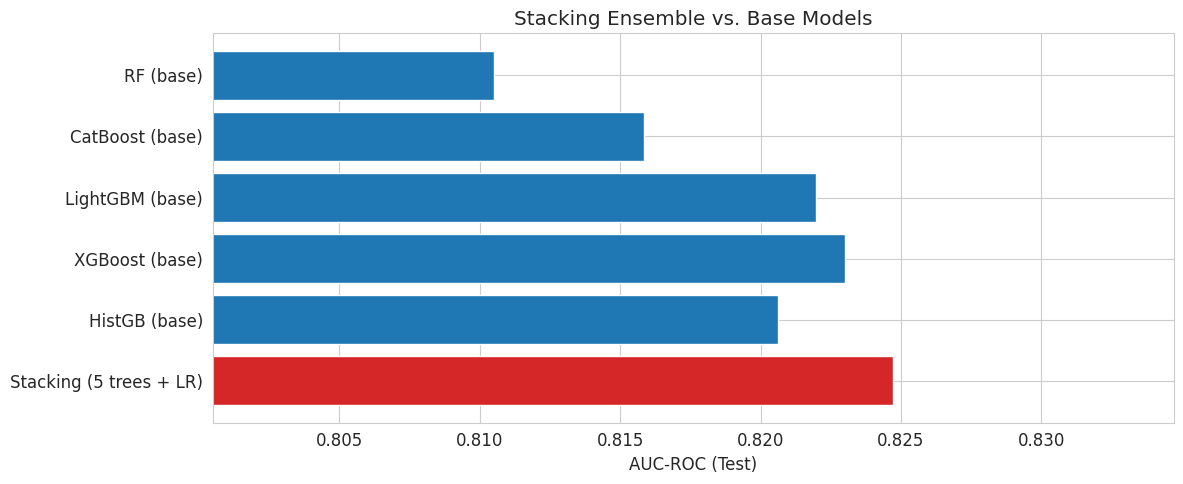

AUC_CV_2std,▁
AUC_CV_mean,▁
AUC_test,▁
AUC_val,▁
Acc_test,▁
F1_test,▁
AUC_CV_2std,0.00379
AUC_CV_mean,0.82282
AUC_test,0.82472
AUC_val,0.82708
Acc_test,0.74379


In [4]:
# Celda 4 — Stacking Ensemble (4 GBDTs + RF → LogisticRegression)
# StackingClassifier: entrena base models con 5-fold CV out-of-fold,
# apila predict_proba como meta-features, entrena meta-learner encima.
# Base models: 4 gradient boosting variants + Random Forest.
# Meta-learner: LogisticRegression (simple, interpretable).
# Ref: Grinsztajn et al. (2022), Wolpert (1992).

nombre_modelo = "Stacking (5 trees + LR)"

wandb.init(project="higgs-boson", name="Stacking", config={
    "base_models": ["HistGB", "XGBoost", "LightGBM", "CatBoost", "RF"],
    "meta_learner": "LogisticRegression(C=1)",
    "cv_folds": 5,
})
print(f"Entrenando {nombre_modelo}...")

# Base models con parámetros razonables (sin grid search individual)
base_models = [
    ("HistGB", HistGradientBoostingClassifier(
        learning_rate=0.1, max_leaf_nodes=127, max_iter=300,
        early_stopping=True, validation_fraction=0.1,
        scoring="roc_auc", random_state=42
    )),
    ("XGBoost", XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=8,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="auc", random_state=42, n_jobs=-1, verbosity=0
    )),
    ("LightGBM", LGBMClassifier(
        n_estimators=200, learning_rate=0.1, num_leaves=127,
        subsample=0.8, feature_fraction=0.8,
        metric="auc", random_state=42, n_jobs=-1, verbose=-1
    )),
    ("CatBoost", CatBoostClassifier(
        iterations=200, learning_rate=0.1, depth=8,
        l2_leaf_reg=3, eval_metric="AUC",
        random_seed=42, thread_count=-1, verbose=False
    )),
    ("RF", RandomForestClassifier(
        n_estimators=200, max_depth=20, random_state=42, n_jobs=-1
    )),
]

# Stacking con 5-fold CV
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(C=1.0, max_iter=2000, random_state=42),
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    stack_method="predict_proba",
    n_jobs=-1,
    verbose=1,
)

print("Entrenando stacking (5-fold CV out-of-fold para meta-features)...")
stacking.fit(X_train, y_train)

# Evaluar stacking
result = evaluar_modelo_cv(stacking, X_train, y_train, X_val, y_val,
                            X_test, y_test, nombre_modelo, use_scaler=False)

print("\n--- Stacking Ensemble ---")
print(tabla_resultados([result]).to_string())

# Comparar con cada base model individual
print("\n--- Base Models (individual, para comparación) ---")
resultados_base = []
base_names = ["HistGB (base)", "XGBoost (base)", "LightGBM (base)", "CatBoost (base)", "RF (base)"]
for (name, model), bname in zip(base_models, base_names):
    r = evaluar_modelo_cv(model, X_train, y_train, X_val, y_val,
                           X_test, y_test, bname, use_scaler=False)
    resultados_base.append(r)

print(tabla_resultados(resultados_base).to_string())

# Comparativa visual
todos = [result] + resultados_base
df_comp = tabla_resultados(todos)
aucs_test = [r["AUC_test"] for r in todos]
labels = [r["Modelo"] for r in todos]

plt.figure(figsize=(12, 5))
colors = ["#d62728" if "Stacking" in l else "#1f77b4" for l in labels]
plt.barh(labels, aucs_test, color=colors)
plt.xlabel("AUC-ROC (Test)")
plt.title("Stacking Ensemble vs. Base Models")
plt.xlim(min(aucs_test) - 0.01, max(aucs_test) + 0.01)
plt.tight_layout()
plt.savefig(DRIVE_PATH + "fig_stacking_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()

wandb.log({
    "AUC_CV_mean": result["AUC_CV_mean"],
    "AUC_CV_2std": 2 * result["AUC_CV_std"],
    "AUC_val": result["AUC_val"],
    "AUC_test": result["AUC_test"],
    "F1_test": result["F1_test"],
    "Acc_test": result["Acc_test"],
})
wandb.finish()

In [5]:
# Celda 5 — Guardar resultado y modelo
df_result = tabla_resultados([result])
print(df_result.to_string())

safe_name = nombre_modelo.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "").replace("=", "").replace(",", "")
df_result.to_csv(DRIVE_PATH + f"resultado_{safe_name}.csv")

# Guardar modelo stacking
with open(DRIVE_PATH + f"modelo_{safe_name}.pkl", "wb") as f:
    pickle.dump({"model": result["_model"], "scaler": result["_scaler"]}, f)

print(f"\nArtefactos guardados: resultado_{safe_name}.csv + modelo_{safe_name}.pkl")

# También guardar resultados de base models
df_bases = tabla_resultados(resultados_base)
safe_names_bases = []
for r in resultados_base:
    sn = r["Modelo"].replace(" ", "_").replace("(", "").replace(")", "").replace(".", "").replace("=", "").replace(",", "")
    df_single = tabla_resultados([r])
    df_single.to_csv(DRIVE_PATH + f"resultado_{sn}.csv")
    with open(DRIVE_PATH + f"modelo_{sn}.pkl", "wb") as f:
        pickle.dump({"model": r["_model"], "scaler": r["_scaler"]}, f)
    safe_names_bases.append(sn)
print(f"Base models guardados: {safe_names_bases}")

                        AUC CV (mean±2σ) AUC Val AUC Test F1 Test Acc Test Precision Test Recall Test
Modelo                                                                                               
Stacking (5 trees + LR)    0.823 ± 0.004   0.827    0.825   0.760    0.744          0.754       0.767

Artefactos guardados: resultado_Stacking_5_trees_+_LR.csv + modelo_Stacking_5_trees_+_LR.pkl
Base models guardados: ['HistGB_base', 'XGBoost_base', 'LightGBM_base', 'CatBoost_base', 'RF_base']
